# Introduction

The **Water Jug Problem** is a classic puzzle in artificial intelligence (AI) that involves using two jugs with different capacities to measure a specific amount of water. It is a popular problem to teach problem-solving techniques in AI, particularly when introducing search algorithms. The Water Jug Problem highlights the application of AI to real-world puzzles by breaking down a complex problem into a series of states and transitions that a machine can solve using an intelligent algorithm.

## Learning

How search algorithms like Breadth-First Search (BFS) can be used to solve it.

## Problem Description

The Water Jug Problem typically involves two jugs with different capacities. The objective is to measure a specific quantity of water by performing operations like filling a jug, emptying a jug, or transferring water between the two jugs. The problem can be stated as follows:

You are given two jugs, one with a capacity of X liters and the other with a capacity of Y liters.
You need to measure exactly Z liters of water using these two jugs.

The allowed operations are:
- Fill one of the jugs.
- Empty one of the jugs.
- Pour water from one jug into another until one jug is either full or empty.

## Significance of the solution

The solution to the problem involves finding the sequence of actions that leads to the desired amount of water. This problem is a simplified version of real-world situations where limited resources and constraints must be managed. For example, it can be compared to industrial processes where tanks of varying capacities must distribute fluids efficiently.

## State Space Representation

In AI terms, the Water Jug Problem can be described using a state space representation, where:

Each state is represented by a tuple (a, b), where a is the amount of water in the first jug and b is the amount of water in the second jug.
The initial state is (0, 0), meaning both jugs are empty.
The goal state is any configuration (a, b) where a or b equals the desired amount Z.
Transitions between states occur when one of the allowed operations is performed.

## Search Algorithms to Solve the Water Jug Problem
To solve the Water Jug Problem using AI techniques, we can apply search algorithms like Breadth-First Search (BFS) and Depth-First Search (DFS). These algorithms systematically explore the state space to find the optimal sequence of operations that leads to the goal state.

1. Breadth-First Search (BFS)

- BFS explores all possible states level by level, ensuring that the shortest path (fewest operations) is found. It is particularly useful for the Water Jug Problem as it guarantees finding the optimal solution.
- BFS starts from the initial state (0, 0) and explores all neighboring states, then their neighbors, and so on until the goal state is found.

2. Depth-First Search (DFS)

- DFS explores each path from the initial state as deeply as possible before backtracking. While DFS can find a solution, it does not guarantee the optimal one and may result in exploring longer paths unnecessarily.
- DFS works well for smaller problems but may struggle with larger state spaces due to its depth-first nature.

## Question

For instance, given 2 jugs with capacities of 3 liters and 5 liters, and a goal of measuring 4 liters, the search for a solution begins from the initial state and moves through various possible states by filling, emptying, and pouring the water between the 2 jugs.

Here we will use BFS.

# Solution

## Defining the State Space

We represent each state as a pair (x, y) where:
- x is the amount of water in the 3-liter jug.
- y is the amount of water in the 5-liter jug.

The initial state is (0, 0) because both jugs start empty, and the goal is to reach any state where either jug contains exactly 4 liters of water.

## Operations in State Space

The following operations define the possible transitions from one state to another:
- Fill the 3-liter jug: Move to (3, y).
- Fill the 5-liter jug: Move to (x, 5).
- Empty the 3-liter jug: Move to (0, y).
- Empty the 5-liter jug: Move to (x, 0).
- Pour water from the 3-liter jug into the 5-liter jug: Move to (max(0, x - (5 - y)), min(5, x + y)).
- Pour water from the 5-liter jug into the 3-liter jug: Move to (min(3, x + y), max(0, y - (3 - x))).

### Function to perform BFS to solve the water jug problem

In [1]:
def water_jug_dfs(capacity1, capacity2, target):
    visited = set()  # To track visited states
    path = []  # To store the solution path

    def dfs(jug1, jug2):
        # If we have already visited this state, return False (to avoid cycles)
        if (jug1, jug2) in visited:
            return False
        
        # Mark the state as visited
        visited.add((jug1, jug2))

        # Append the current state to the path
        path.append((jug1, jug2))

        # If the target is achieved in either jug, return True
        if jug1 == target or jug2 == target:
            return True

        # Explore all possible transitions (DFS recursive calls)
        
        # Fill 3-liter jug
        if dfs(3, jug2):
            return True
        # Fill 5-liter jug
        if dfs(jug1, 5):
            return True
        # Empty 3-liter jug
        if dfs(0, jug2):
            return True
        # Empty 5-liter jug
        if dfs(jug1, 0):
            return True
        # Pour water from 3-liter jug into 5-liter jug
        if dfs(max(0, jug1 - (5 - jug2)), min(5, jug1 + jug2)):
            return True
        # Pour water from 5-liter jug into 3-liter jug
        if dfs(min(3, jug1 + jug2), max(0, jug2 - (3 - jug1))):
            return True

        # If none of the transitions lead to the goal, backtrack
        path.pop()
        return False

    # Start DFS from the initial state (0, 0)
    dfs(0, 0)

    # If we found a solution, return the path
    return path

### Example Usage

In [2]:
capacity1 = 3  # Capacity of the 3-liter jug
capacity2 = 5  # Capacity of the 5-liter jug
target = 4     # Target amount to measure

solution = water_jug_dfs(capacity1, capacity2, target)

if solution:
    print("Solution steps:")
    for step in solution:
        print(step)
else:
    print("No solution found.")

Solution steps:
(0, 0)
(3, 0)
(3, 5)
(0, 5)
(3, 2)
(0, 2)
(2, 0)
(2, 5)
(3, 4)


### Installing Packages

In [3]:
%pip install matplotlib networkx

Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

### Function to create and visualize the state space transitions for BFS

In [5]:
def water_jug_bfs(capacity1, capacity2, target):
    start = (0, 0)
    queue = deque([(start, [start])])
    visited = {start}

    while queue:
        (jug1, jug2), path = queue.popleft()

        if jug1 == target or jug2 == target:
            return path

        next_states = [
            (capacity1, jug2),
            (jug1, capacity2),
            (0, jug2),
            (jug1, 0),
            (max(0, jug1 - (capacity2 - jug2)), min(capacity2, jug1 + jug2)),
            (min(capacity1, jug1 + jug2), max(0, jug2 - (capacity1 - jug1))),
        ]

        for state in next_states:
            if state not in visited:
                visited.add(state)
                queue.append((state, path + [state]))

    return []

bfs_solution = water_jug_bfs(capacity1, capacity2, target)

if bfs_solution:
    print("BFS solution steps:")
    for step in bfs_solution:
        print(step)
else:
    print("No solution found via BFS.")

BFS solution steps:
(0, 0)
(0, 5)
(3, 2)
(0, 2)
(2, 0)
(2, 5)
(3, 4)


### Visualize the graph

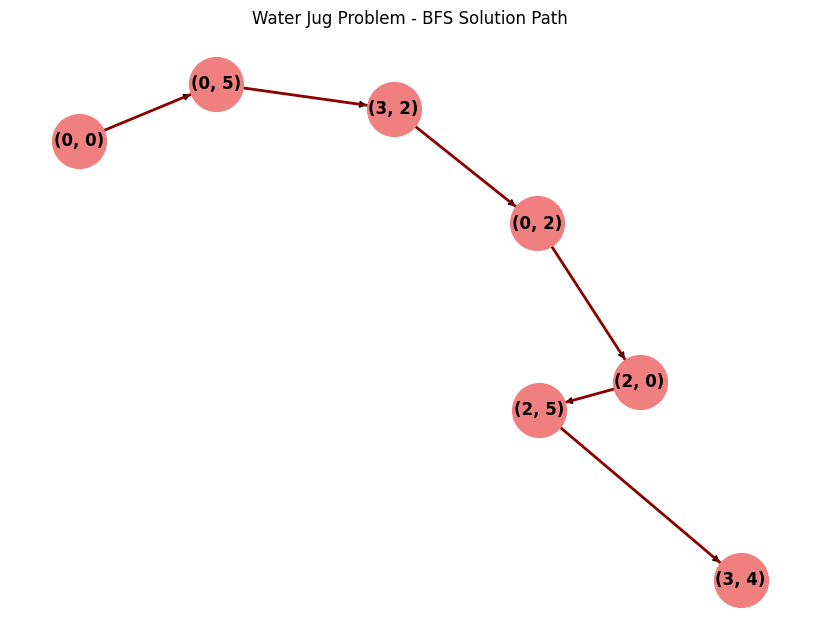

In [6]:
def visualize_bfs_solution(solution):
    G = nx.DiGraph()

    for i in range(len(solution) - 1):
        G.add_edge(solution[i], solution[i + 1])

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(8, 6))

    nx.draw(G, pos, with_labels=True, node_color="lightcoral", node_size=1500, font_size=12, font_weight="bold")
    nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()), edge_color="darkred", width=2)

    plt.title("Water Jug Problem - BFS Solution Path")
    plt.show()

if bfs_solution:
    visualize_bfs_solution(bfs_solution)